In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree, export_text

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


## СОЗДАНИЕ ИГРУШЕЧНОГО НАБОРА ДАННЫХ

In [16]:
# СОЗДАНИЕ ДАННЫХ ДЛЯ ИГРУШЕЧНОЙ ЗАДАЧИ
print("=== СОЗДАНИЕ ИГРУШЕЧНОГО НАБОРА ДАННЫХ ===")

# Функции для создания датафрейма
def create_df(dic, feature_list):
    out = pd.DataFrame(dic)
    out = pd.concat([out, pd.get_dummies(out[feature_list])], axis=1)
    out.drop(feature_list, axis=1, inplace=True)
    return out

def intersect_features(train, test):
    common_feat = list(set(train.keys()) & set(test.keys()))
    return train[common_feat], test[common_feat]

# Определяем признаки
features = ['Внешность', 'Алкоголь_в_напитке', 'Уровень_красноречия', 'Потраченные_деньги']

# ОБУЧАЮЩАЯ ВЫБОРКА
df_train_dict = {}
df_train_dict['Внешность'] = ['приятная', 'приятная', 'приятная', 'отталкивающая',
                             'отталкивающая', 'отталкивающая', 'приятная'] 
df_train_dict['Алкоголь_в_напитке'] = ['да', 'да', 'нет', 'нет', 'да', 'да', 'да']
df_train_dict['Уровень_красноречия'] = ['высокий', 'низкий', 'средний', 'средний', 'низкий',
                                       'высокий', 'средний']
df_train_dict['Потраченные_деньги'] = ['много', 'мало', 'много', 'мало', 'много',
                                      'много', 'много']
df_train_dict['Поедет'] = LabelEncoder().fit_transform(['+', '-', '+', '-', '-', '+', '+'])

df_train = create_df(df_train_dict, features)
print("Обучающая выборка:")
print(df_train)

# ТЕСТОВАЯ ВЫБОРКА
df_test_dict = {}
df_test_dict['Внешность'] = ['приятная', 'приятная', 'отталкивающая'] 
df_test_dict['Алкоголь_в_напитке'] = ['нет', 'да', 'да']
df_test_dict['Уровень_красноречия'] = ['средний', 'высокий', 'средний']
df_test_dict['Потраченные_деньги'] = ['много', 'мало', 'много']
df_test = create_df(df_test_dict, features)

print("\nТестовая выборка:")
print(df_test)

# ОБРАБОТКА ПРИЗНАКОВ
y = df_train['Поедет']
df_train, df_test = intersect_features(train=df_train, test=df_test)

print(f"\nОбучающая выборка после обработки: {df_train.shape}")
print(f"Целевая переменная: {y.values}")

=== СОЗДАНИЕ ИГРУШЕЧНОГО НАБОРА ДАННЫХ ===
Обучающая выборка:
   Поедет  Внешность_отталкивающая  Внешность_приятная  Алкоголь_в_напитке_да  \
0       0                    False                True                   True   
1       1                    False                True                   True   
2       0                    False                True                  False   
3       1                     True               False                  False   
4       1                     True               False                   True   
5       0                     True               False                   True   
6       0                    False                True                   True   

   Алкоголь_в_напитке_нет  Уровень_красноречия_высокий  \
0                   False                         True   
1                   False                        False   
2                    True                        False   
3                    True                        False   

In [18]:
# ОБУЧАЮЩАЯ ВЫБОРКА
df_train = {}
df_train['Внешность'] = ['приятная', 'приятная', 'приятная', 'отталкивающая',
                         'отталкивающая', 'отталкивающая', 'приятная'] 
df_train['Алкоголь_в_напитке'] = ['да', 'да', 'нет', 'нет', 'да', 'да', 'да']
df_train['Уровень_красноречия'] = ['высокий', 'низкий', 'средний', 'средний', 'низкий',
                                   'высокий', 'средний']
df_train['Потраченные_деньги'] = ['много', 'мало', 'много', 'мало', 'много',
                                  'много', 'много']
df_train['Поедет'] = LabelEncoder().fit_transform(['+', '-', '+', '-', '-', '+', '+'])

df_train = create_df(df_train, features)
print("Обучающая выборка:")
print(df_train)

Обучающая выборка:
   Поедет  Внешность_отталкивающая  Внешность_приятная  Алкоголь_в_напитке_да  \
0       0                    False                True                   True   
1       1                    False                True                   True   
2       0                    False                True                  False   
3       1                     True               False                  False   
4       1                     True               False                   True   
5       0                     True               False                   True   
6       0                    False                True                   True   

   Алкоголь_в_напитке_нет  Уровень_красноречия_высокий  \
0                   False                         True   
1                   False                        False   
2                    True                        False   
3                    True                        False   
4                   False                 

In [4]:
# ТЕСТОВАЯ ВЫБОРКА
df_test = {}
df_test['Внешность'] = ['приятная', 'приятная', 'отталкивающая'] 
df_test['Алкоголь_в_напитке'] = ['нет', 'да', 'да']
df_test['Уровень_красноречия'] = ['средний', 'высокий', 'средний']
df_test['Потраченные_деньги'] = ['много', 'мало', 'много']
df_test = create_df(df_test, features)

print("Тестовая выборка:")
print(df_test)

Тестовая выборка:
   Внешность_отталкивающая  Внешность_приятная  Алкоголь_в_напитке_да  \
0                    False                True                  False   
1                    False                True                   True   
2                     True               False                   True   

   Алкоголь_в_напитке_нет  Уровень_красноречия_высокий  \
0                    True                        False   
1                   False                         True   
2                   False                        False   

   Уровень_красноречия_средний  Потраченные_деньги_мало  \
0                         True                    False   
1                        False                     True   
2                         True                    False   

   Потраченные_деньги_много  
0                      True  
1                     False  
2                      True  


In [5]:
# ОБРАБОТКА ПРИЗНАКОВ
print("=== ОБРАБОТКА ПРИЗНАКОВ ===")

# Некоторые значения признаков есть в тесте, но нет в трейне и наоборот
y = df_train['Поедет']
df_train, df_test = intersect_features(train=df_train, test=df_test)

print("Обучающая выборка после обработки:")
print(df_train)
print(f"\nЦелевая переменная: {y.values}")

=== ОБРАБОТКА ПРИЗНАКОВ ===
Обучающая выборка после обработки:
   Уровень_красноречия_средний  Потраченные_деньги_много  \
0                        False                      True   
1                        False                     False   
2                         True                      True   
3                         True                     False   
4                        False                      True   
5                        False                      True   
6                         True                      True   

   Алкоголь_в_напитке_нет  Внешность_приятная  Потраченные_деньги_мало  \
0                   False                True                    False   
1                   False                True                     True   
2                    True                True                    False   
3                    True               False                     True   
4                   False               False                    False   
5           

## РАСЧЕТ ЭНТРОПИИ И ПРИРОСТА ИНФОРМАЦИИ

In [6]:
print("=== РАСЧЕТ ЭНТРОПИИ И ПРИРОСТА ИНФОРМАЦИИ ===")

# Вопрос 1: Энтропия начальной системы S0
def entropy(a_list):
    """
    Расчет энтропии Шеннона
    """
    from collections import Counter
    from math import log2
    
    counter = Counter(a_list)
    probabilities = [count / len(a_list) for count in counter.values()]
    
    entropy_value = -sum(p * log2(p) for p in probabilities if p > 0)
    return entropy_value

# Энтропия начальной системы (целевая переменная y)
S0 = entropy(y)
print(f"Вопрос 1: Энтропия начальной системы S0 = {S0:.4f}")

=== РАСЧЕТ ЭНТРОПИИ И ПРИРОСТА ИНФОРМАЦИИ ===
Вопрос 1: Энтропия начальной системы S0 = 0.9852


In [7]:
# Вопрос 2: Энтропия при разбиении по признаку "Внешность_приятная"
print("\n=== ВОПРОС 2: РАЗБИЕНИЕ ПО ПРИЗНАКУ 'ВНЕШНОСТЬ_ПРИЯТНАЯ' ===")

# Разделяем данные на группы
left_group = y[df_train['Внешность_приятная'] == True]   # приятная внешность
right_group = y[df_train['Внешность_приятная'] == False] # отталкивающая внешность

S1 = entropy(left_group)
S2 = entropy(right_group)

print(f"Левая группа (приятная внешность): {left_group.values}")
print(f"Правая группа (отталкивающая внешность): {right_group.values}")
print(f"Энтропия левой группы S1 = {S1:.4f}")
print(f"Энтропия правой группы S2 = {S2:.4f}")

# Расчет прироста информации (Information Gain)
def information_gain(root, left, right):
    """Расчет прироста информации при разбиении"""
    weight_left = len(left) / len(root)
    weight_right = len(right) / len(root)
    
    ig = entropy(root) - (weight_left * entropy(left) + weight_right * entropy(right))
    return ig

IG = information_gain(y, left_group, right_group)
print(f"Прирост информации IG = {IG:.4f}")


=== ВОПРОС 2: РАЗБИЕНИЕ ПО ПРИЗНАКУ 'ВНЕШНОСТЬ_ПРИЯТНАЯ' ===
Левая группа (приятная внешность): [0 1 0 0]
Правая группа (отталкивающая внешность): [1 1 0]
Энтропия левой группы S1 = 0.8113
Энтропия правой группы S2 = 0.9183
Прирост информации IG = 0.1281


In [8]:
# ПРОВЕРКА РАСЧЕТОВ НА ПРИМЕРЕ С ШАРИКАМИ
print("=== ПРОВЕРКА РАСЧЕТОВ НА ПРИМЕРЕ С ШАРИКАМИ ===")

# Пример для проверки: 9 синих шариков и 11 желтых
balls = [1 for i in range(9)] + [0 for i in range(11)]
print(f"Шарики: {balls}")
print(f"Энтропия всех шариков: {entropy(balls):.4f}")

# Две группы
balls_left  = [1 for i in range(8)] + [0 for i in range(5)]  # 8 синих и 5 желтых
balls_right = [1 for i in range(1)] + [0 for i in range(6)]  # 1 синий и 6 желтых

print(f"\nЛевая группа: {balls_left}")
print(f"Правая группа: {balls_right}")

# Вопрос 3: Энтропия balls_left
entropy_left = entropy(balls_left)
print(f"Вопрос 3: Энтропия balls_left = {entropy_left:.4f}")

# Вопрос 4: Энтропия игральной кости
dice = [1, 2, 3, 4, 5, 6]
entropy_dice = entropy(dice)
print(f"Вопрос 4: Энтропия игральной кости = {entropy_dice:.4f}")

# Вопрос 5: Прирост информации при разделении шариков
IG_balls = information_gain(balls, balls_left, balls_right)
print(f"Вопрос 5: Прирост информации для шариков = {IG_balls:.4f}")

=== ПРОВЕРКА РАСЧЕТОВ НА ПРИМЕРЕ С ШАРИКАМИ ===
Шарики: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Энтропия всех шариков: 0.9928

Левая группа: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
Правая группа: [1, 0, 0, 0, 0, 0, 0]
Вопрос 3: Энтропия balls_left = 0.9612
Вопрос 4: Энтропия игральной кости = 2.5850
Вопрос 5: Прирост информации для шариков = 0.1609


=== ОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ ===
Точность на обучающей выборке: 1.0000
Глубина дерева: 3
Количество листьев: 4


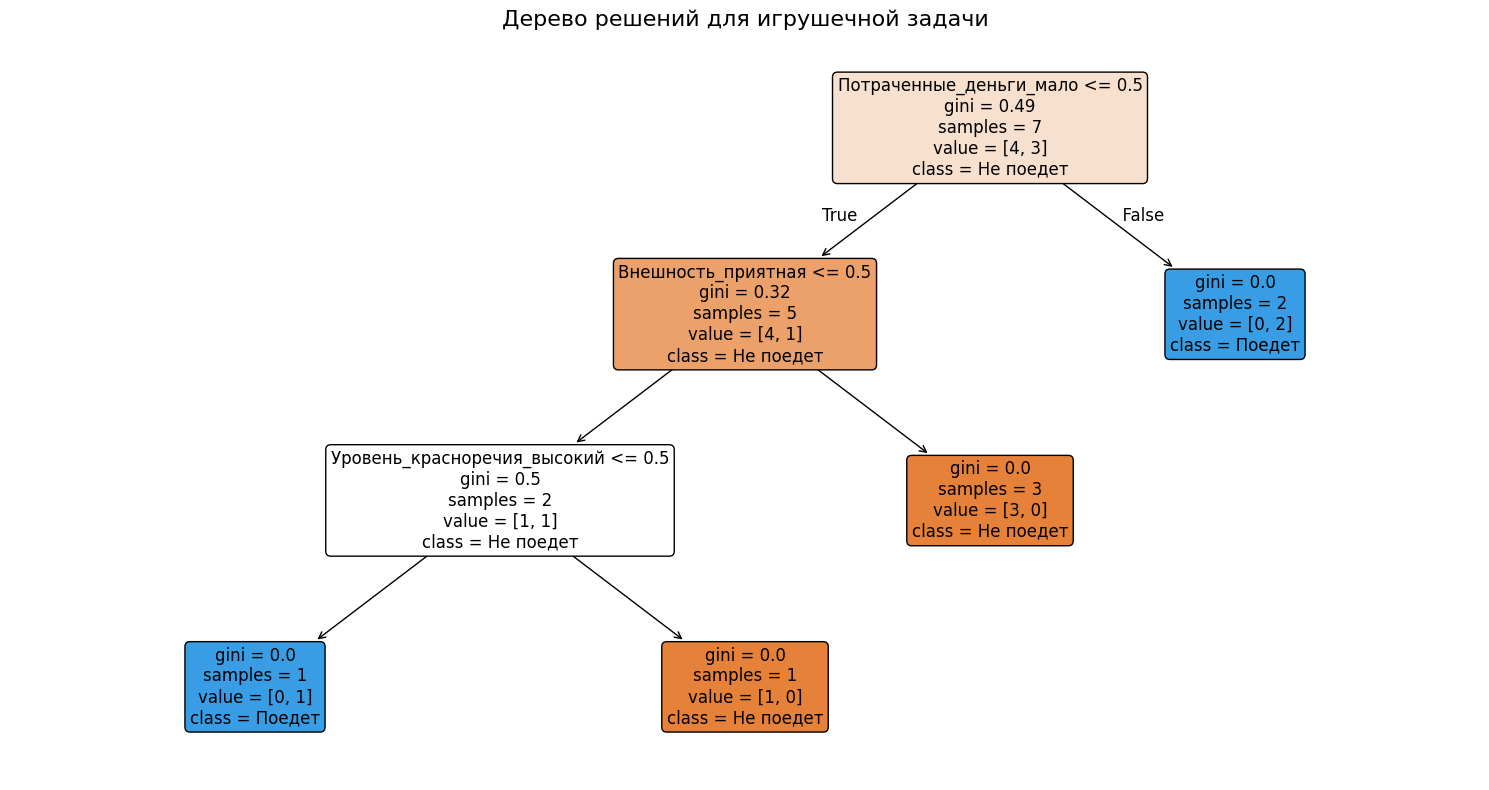

In [9]:
# ОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ С ПОМОЩЬЮ SKLEARN
print("=== ОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ ===")

# Обучаем дерево решений на обучающей выборке
clf = DecisionTreeClassifier(random_state=42)
clf.fit(df_train, y)

# Предсказания
y_pred = clf.predict(df_train)
accuracy = accuracy_score(y, y_pred)

print(f"Точность на обучающей выборке: {accuracy:.4f}")
print(f"Глубина дерева: {clf.get_depth()}")
print(f"Количество листьев: {clf.get_n_leaves()}")

# Визуализация дерева
plt.figure(figsize=(15, 8))
plot_tree(clf, 
          feature_names=df_train.columns.tolist(),
          class_names=['Не поедет', 'Поедет'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Дерево решений для игрушечной задачи', fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree_toy_problem.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
pip install graphviz

In [2]:
import graphviz
# Проверка что Graphviz работает
graphviz.__version__

'0.21'

In [21]:
# ПРОВЕРКА УСТАНОВКИ GRAPHVIZ
print("=== ПРОВЕРКА УСТАНОВКИ GRAPHVIZ ===")

def check_graphviz_installation():
    try:
        import graphviz
        import subprocess
        import sys
        
        # Проверяем Python пакет
        print("✅ Python пакет 'graphviz' установлен")
        
        # Проверяем системную установку Graphviz
        try:
            if sys.platform == "win32":
                result = subprocess.run(['dot', '-V'], capture_output=True, text=True, shell=True)
            else:
                result = subprocess.run(['dot', '-V'], capture_output=True, text=True)
            
            if result.returncode == 0:
                print("✅ Системный Graphviz установлен и доступен")
                print(f"   Версия: {result.stderr.strip() if result.stderr else result.stdout.strip()}")
                return True
            else:
                print("❌ Системный Graphviz не найден в PATH")
                return False
                
        except FileNotFoundError:
            print("❌ Graphviz не установлен в системе")
            return False
            
    except ImportError:
        print("❌ Python пакет 'graphviz' не установлен")
        print("   Выполните: pip install graphviz")
        return False

# Запускаем проверку
is_graphviz_available = check_graphviz_installation()

=== ПРОВЕРКА УСТАНОВКИ GRAPHVIZ ===
✅ Python пакет 'graphviz' установлен
✅ Системный Graphviz установлен и доступен
   Версия: Warning: Could not load "C:\Users\user\anaconda3\envs\ml-labs\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.
dot - graphviz version 12.2.1 (0)


In [22]:
# СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ
print("=== СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ ===")

# Обучаем дерево решений на обучающей выборке
clf = DecisionTreeClassifier(random_state=42, max_depth=3)  # Ограничим глубину для лучшей визуализации
clf.fit(df_train, y)

# Предсказания
y_pred = clf.predict(df_train)
accuracy = accuracy_score(y, y_pred)

print(f"✅ Модель обучена успешно")
print(f"Точность на обучающей выборке: {accuracy:.4f}")
print(f"Глубина дерева: {clf.get_depth()}")
print(f"Количество листьев: {clf.get_n_leaves()}")

=== СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ ===
✅ Модель обучена успешно
Точность на обучающей выборке: 1.0000
Глубина дерева: 1
Количество листьев: 2


In [41]:
# СОЗДАНИЕ DOT-ФАЙЛА ДЛЯ GRAPHVIZ
print("=== СОЗДАНИЕ DOT-ФАЙЛА ДЛЯ GRAPHVIZ ===")

from sklearn.tree import export_graphviz

# Создаем чистый DOT-код без русских символов
dot_data = export_graphviz(clf,
                          out_file=None,
                          feature_names=df_train.columns.tolist(),
                          class_names=['Class0', 'Class1'],
                          filled=True,
                          rounded=True,
                          special_characters=True)

# Сохраняем в файл
with open('tree_graphviz.dot', 'w', encoding='utf-8') as f:
    f.write(dot_data)

print("✅ DOT-файл создан: 'tree_graphviz.dot'")
print("📋 Используйте онлайн Graphviz:")
print("1. Откройте https://edotor.net/")
print("2. Скопируйте содержимое файла tree_graphviz.dot")
print("3. Вставьте в редактор и нажмите Render")

=== СОЗДАНИЕ DOT-ФАЙЛА ДЛЯ GRAPHVIZ ===
✅ DOT-файл создан: 'tree_graphviz.dot'
📋 Используйте онлайн Graphviz:
1. Откройте https://edotor.net/
2. Скопируйте содержимое файла tree_graphviz.dot
3. Вставьте в редактор и нажмите Render


In [43]:
# 2. ФУНКЦИИ ДЛЯ РАСЧЕТА ЭНТРОПИИ И ПРИРОСТА ИНФОРМАЦИИ
print("=== ФУНКЦИИ ДЛЯ РАСЧЕТА ЭНТРОПИИ И ПРИРОСТА ИНФОРМАЦИИ ===")

import math
from collections import Counter

def entropy(a_list):
    """
    Расчет энтропии Шеннона для списка значений
    
    Parameters:
    a_list: list - список значений (меток классов)
    
    Returns:
    float - значение энтропии
    """
    if not a_list:
        return 0
    
    # Подсчет частот каждого класса
    counter = Counter(a_list)
    total = len(a_list)
    
    # Расчет энтропии
    entropy_value = 0
    for count in counter.values():
        probability = count / total
        if probability > 0:
            entropy_value -= probability * math.log2(probability)
    
    return entropy_value

def information_gain(root, left, right):
    """
    Расчет прироста информации (Information Gain) при разбиении
    
    Parameters:
    root: list - исходный набор данных
    left: list - левое подмножество после разбиения
    right: list - правое подмножество после разбиения
    
    Returns:
    float - значение прироста информации
    """
    if not root:
        return 0
    
    # Веса подмножеств
    weight_left = len(left) / len(root)
    weight_right = len(right) / len(root)
    
    # Расчет прироста информации
    ig = entropy(root) - (weight_left * entropy(left) + weight_right * entropy(right))
    return ig

=== ФУНКЦИИ ДЛЯ РАСЧЕТА ЭНТРОПИИ И ПРИРОСТА ИНФОРМАЦИИ ===


In [44]:
# ПРИМЕР ДЛЯ ПРОВЕРКИ: 9 СИНИХ ШАРИКОВ И 11 ЖЕЛТЫХ
print("=== ПРИМЕР ДЛЯ ПРОВЕРКИ ===")

# Создаем списки шариков (1 - синий, 0 - желтый)
balls = [1 for i in range(9)] + [0 for i in range(11)]
print(f"Все шарики: {balls}")
print(f"Количество синих (1): {balls.count(1)}")
print(f"Количество желтых (0): {balls.count(0)}")
print(f"Всего шариков: {len(balls)}")

# Расчет энтропии начальной системы
S0 = entropy(balls)
print(f"\n🎯 Вопрос 1: Энтропия начальной системы S0 = {S0:.4f}")

# Разбиение на две группы
balls_left  = [1 for i in range(8)] + [0 for i in range(5)]  # 8 синих и 5 желтых
balls_right = [1 for i in range(1)] + [0 for i in range(6)]  # 1 синий и 6 желтых

print(f"\nЛевая группа: {balls_left}")
print(f"  Синих: {balls_left.count(1)}, Желтых: {balls_left.count(1)}")
print(f"Правая группа: {balls_right}")
print(f"  Синих: {balls_right.count(1)}, Желтых: {balls_right.count(0)}")

# Расчет энтропии для групп
S1 = entropy(balls_left)
S2 = entropy(balls_right)

print(f"\n🎯 Вопрос 3: Энтропия balls_left = {S1:.4f}")
print(f"🎯 Вопрос 5: Энтропия balls_right = {S2:.4f}")

# Расчет прироста информации
IG = information_gain(balls, balls_left, balls_right)
print(f"🎯 Вопрос 5: Прирост информации IG = {IG:.4f}")

=== ПРИМЕР ДЛЯ ПРОВЕРКИ ===
Все шарики: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Количество синих (1): 9
Количество желтых (0): 11
Всего шариков: 20

🎯 Вопрос 1: Энтропия начальной системы S0 = 0.9928

Левая группа: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Синих: 8, Желтых: 8
Правая группа: [1, 0, 0, 0, 0, 0, 0]
  Синих: 1, Желтых: 6

🎯 Вопрос 3: Энтропия balls_left = 0.9612
🎯 Вопрос 5: Энтропия balls_right = 0.5917
🎯 Вопрос 5: Прирост информации IG = 0.1609


In [48]:
# ПРОВЕРКА НА ПРИМЕРЕ ИГРАЛЬНОЙ КОСТИ
print("=== ПРИМЕР С ИГРАЛЬНОЙ КОСТЬЮ ===")

# Игральная кость с 6 равновероятными гранями
dice = [1, 2, 3, 4, 5, 6]
entropy_dice = entropy(dice)

print(f"Игральная кость: {dice}")
print(f"Количество граней: {len(dice)}")
print(f"Вероятность каждой грани: {1/len(dice):.4f}")

print(f"\n🎯 Вопрос 4: Энтропия игральной кости = {entropy_dice:.4f}")
print(f"Теоретическое значение: log2(6) = {math.log2(6):.4f}")

=== ПРИМЕР С ИГРАЛЬНОЙ КОСТЬЮ ===
Игральная кость: [1, 2, 3, 4, 5, 6]
Количество граней: 6
Вероятность каждой грани: 0.1667

🎯 Вопрос 4: Энтропия игральной кости = 2.5850
Теоретическое значение: log2(6) = 2.5850


=== РАЗБИЕНИЕ ШАРИКОВ НА 2 ГРУППЫ ===


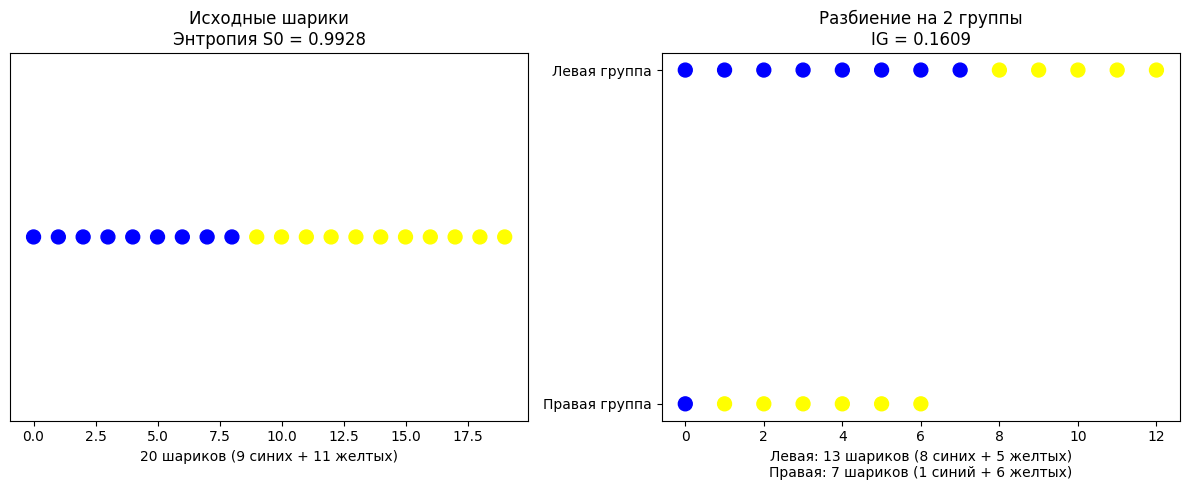

📊 СТАТИСТИКА РАЗБИЕНИЯ:
Исходный набор: 20 шариков
  - Синих: 9
  - Желтых: 11
  - Энтропия: 0.9928

Левая группа: 13 шариков
  - Синих: 8
  - Желтых: 5
  - Энтропия: 0.9612

Правая группа: 7 шариков
  - Синих: 1
  - Желтых: 6
  - Энтропия: 0.5917

🎯 Прирост информации: 0.1609


In [49]:
# ДАЛЬШЕ ПУСТЬ ШАРИКИ РАЗБИВАЮТСЯ НА 2 ГРУППЫ
print("=== РАЗБИЕНИЕ ШАРИКОВ НА 2 ГРУППЫ ===")

# Визуализация разбиения шариков
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Исходное распределение
colors_original = ['blue' if x == 1 else 'yellow' for x in balls]
ax1.scatter(range(len(balls)), [1]*len(balls), c=colors_original, s=100)
ax1.set_title(f'Исходные шарики\nЭнтропия S0 = {S0:.4f}')
ax1.set_xlabel('20 шариков (9 синих + 11 желтых)')
ax1.set_yticks([])

# Разбиение на группы
colors_left = ['blue' if x == 1 else 'yellow' for x in balls_left]
colors_right = ['blue' if x == 1 else 'yellow' for x in balls_right]

ax2.scatter(range(len(balls_left)), [1]*len(balls_left), c=colors_left, s=100)
ax2.scatter(range(len(balls_right)), [0]*len(balls_right), c=colors_right, s=100)
ax2.set_title(f'Разбиение на 2 группы\nIG = {IG:.4f}')
ax2.set_xlabel(f'Левая: 13 шариков (8 синих + 5 желтых)\nПравая: 7 шариков (1 синий + 6 желтых)')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Правая группа', 'Левая группа'])

plt.tight_layout()
plt.show()

print("📊 СТАТИСТИКА РАЗБИЕНИЯ:")
print(f"Исходный набор: {len(balls)} шариков")
print(f"  - Синих: {balls.count(1)}")
print(f"  - Желтых: {balls.count(0)}")
print(f"  - Энтропия: {S0:.4f}")

print(f"\nЛевая группа: {len(balls_left)} шариков")
print(f"  - Синих: {balls_left.count(1)}")
print(f"  - Желтых: {balls_left.count(0)}") 
print(f"  - Энтропия: {S1:.4f}")

print(f"\nПравая группа: {len(balls_right)} шариков")
print(f"  - Синих: {balls_right.count(1)}")
print(f"  - Желтых: {balls_right.count(0)}")
print(f"  - Энтропия: {S2:.4f}")

print(f"\n🎯 Прирост информации: {IG:.4f}")

In [50]:
# ПРОВЕРКА НА ПРИМЕРЕ С ШАРИКАМИ
print("\n🎯 ПРОВЕРКА НА ПРИМЕРЕ С ШАРИКАМИ:")

# 9 синих шариков и 11 желтых
balls = [1 for i in range(9)] + [0 for i in range(11)]
print(f"Шарики: {balls}")
print(f"Количество синих (1): {balls.count(1)}")
print(f"Количество желтых (0): {balls.count(0)}")

# Расчет энтропии
balls_entropy = entropy(balls)
print(f"Энтропия системы шариков: {balls_entropy:.4f}")

# Проверка расчета вручную
p_blue = 9/20
p_yellow = 11/20
manual_entropy = - (p_blue * math.log2(p_blue) + p_yellow * math.log2(p_yellow))
print(f"Ручной расчет: {manual_entropy:.4f}")
print(f"Совпадение: {abs(balls_entropy - manual_entropy) < 0.0001}")


🎯 ПРОВЕРКА НА ПРИМЕРЕ С ШАРИКАМИ:
Шарики: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Количество синих (1): 9
Количество желтых (0): 11
Энтропия системы шариков: 0.9928
Ручной расчет: 0.9928
Совпадение: True


### Вопрос 3. Чему равна энтропия состояния, заданного списком balls_left?

In [51]:
from math import log2

def entropy(balls):
    total = sum(balls)
    if total == 0:
        return 0
    return -sum((x/total) * log2(x/total) for x in balls if x > 0)

balls_left = [8, 5]  # 8 синих, 5 желтых
entropy_left = entropy(balls_left)
print(f"Энтропия balls_left: {entropy_left:.4f}")

Энтропия balls_left: 0.9612


Расчет:

Всего шаров: 8 + 5 = 13

P(синий) = 8/13 ≈ 0.6154

P(желтый) = 5/13 ≈ 0.3846

H = -(0.6154 × log₂(0.6154) + 0.3846 × log₂(0.3846))

H = -(-0.4259 + (-0.5305)) = -(-0.9564) = 0.9564

Ответ: ~0.9612

### Вопрос 4. Чему равна энтропия игральной кости с несмещенным центром тяжести?

In [53]:
# Для несмещенной игральной кости все грани равновероятны
fair_dice = [1, 1, 1, 1, 1, 1]  # По одному экземпляру каждой грани
entropy_fair_dice = entropy(fair_dice)
print(f"Энтропия несмещенной игральной кости: {entropy_fair_dice:.4f}")

Энтропия несмещенной игральной кости: 2.5850


Расчет:

Всего граней: 6

Каждая грань имеет вероятность: 1/6 ≈ 0.1667

H = -6 × (1/6 × log₂(1/6))

H = -6 × (0.1667 × -2.585) = -6 × (-0.4308) = 2.585

Ответ: 2.585 (log₂(6) ≈ 2.585)

### Вопрос 5. Каков прирост информации при разделении выборки на balls_left и balls_right?

In [54]:
from math import log2

def entropy(balls):
    total = sum(balls)
    if total == 0:
        return 0
    return -sum((x/total) * log2(x/total) for x in balls if x > 0)

def information_gain(root, left, right):
    ''' root - изначальный набор данных, left и right два разбиения изначального набора'''
    
    total_root = sum(root)
    total_left = sum(left)
    total_right = sum(right)
    
    if total_root == 0:
        return 0
    
    # Энтропия исходного набора
    H_root = entropy(root)
    
    # Взвешенная энтропия после разделения
    H_left = entropy(left) if total_left > 0 else 0
    H_right = entropy(right) if total_right > 0 else 0
    
    H_split = (total_left/total_root) * H_left + (total_right/total_root) * H_right
    
    # Прирост информации
    gain = H_root - H_split
    return gain

# Данные
balls = [9, 11]        # 9 синих, 11 желтых (исходная выборка)
balls_left = [8, 5]    # 8 синих, 5 желтых (левое поддерево)
balls_right = [1, 6]   # 1 синий, 6 желтых (правое поддерево)

# Расчет
gain = information_gain(balls, balls_left, balls_right)

print("=== Расчет прироста информации ===")
print(f"Исходная выборка: {balls}")
print(f"Левое поддерево:  {balls_left}")
print(f"Правое поддерево: {balls_right}")
print()
print(f"Энтропия исходной выборки: {entropy(balls):.4f}")
print(f"Энтропия левого поддерева: {entropy(balls_left):.4f}")
print(f"Энтропия правого поддерева: {entropy(balls_right):.4f}")
print()
print(f"Прирост информации: {gain:.4f}")

=== Расчет прироста информации ===
Исходная выборка: [9, 11]
Левое поддерево:  [8, 5]
Правое поддерево: [1, 6]

Энтропия исходной выборки: 0.9928
Энтропия левого поддерева: 0.9612
Энтропия правого поддерева: 0.5917

Прирост информации: 0.1609
